In [17]:
from qiskit import QuantumCircuit
import networkx as nx
from qiskit.quantum_info import Statevector, state_fidelity
import math
import matplotlib.pyplot as plt
from IPython.display import display

Random Quantum Circuit Generated
Seed             : 43706
Number of Qubits : 8
Circuit Depth    : 18
Total Gates      : 108


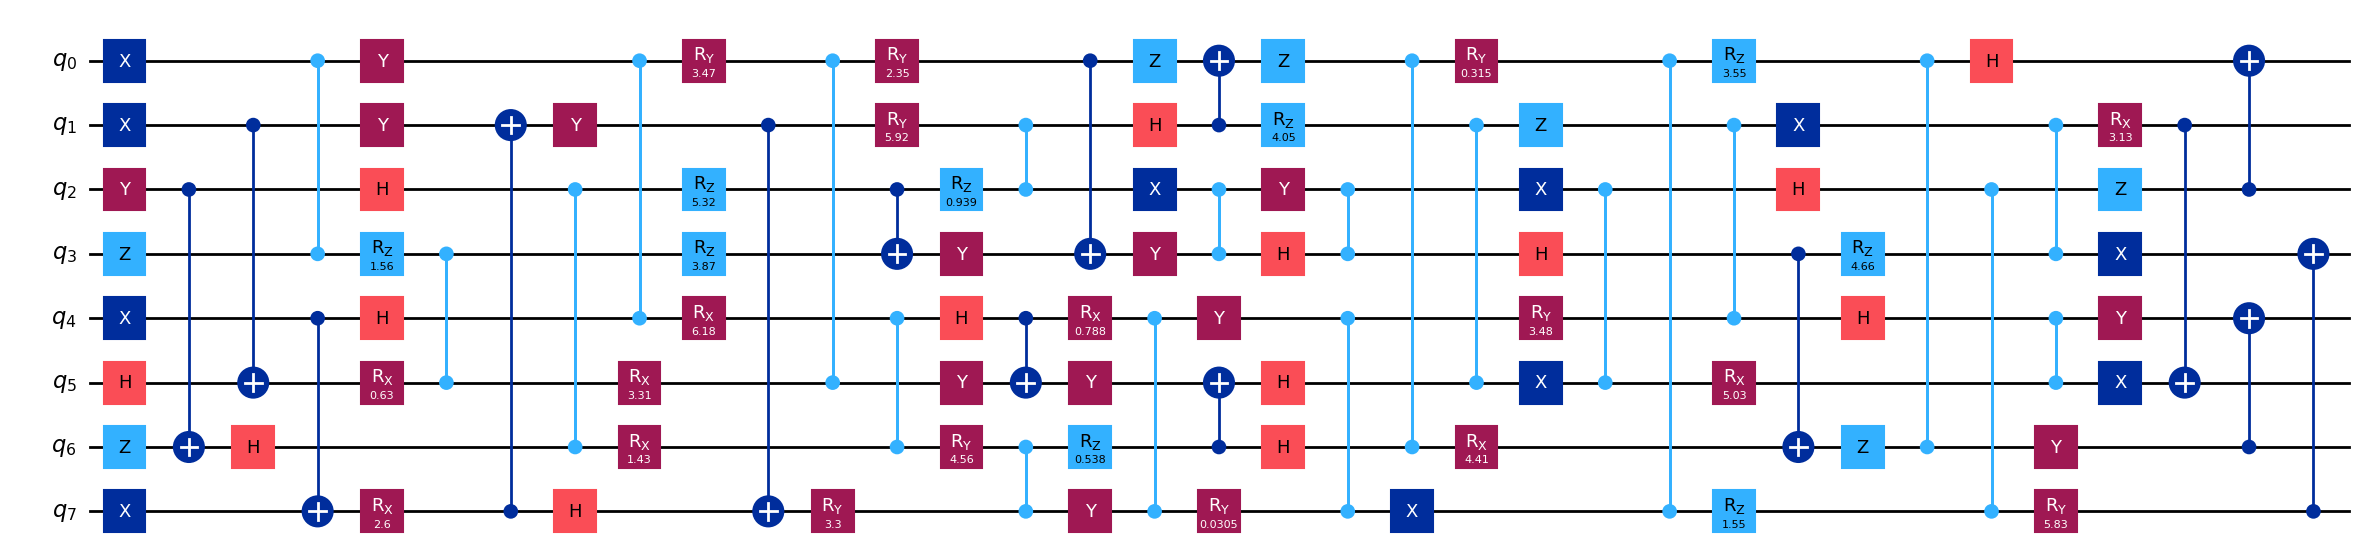

In [3]:
import random
import numpy as np
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt

def generate_random_circuit():
    seed = random.randint(0, 99999)
    random.seed(seed)
    np.random.seed(seed)
    
    num_qubits = random.randint(4, 12)
    depth = random.randint(5, 10)
    qc = QuantumCircuit(num_qubits)
    
    single_gates = ['h', 'x', 'y', 'z', 'rx', 'ry', 'rz']
    two_gates = ['cx', 'cz']
    
    for _ in range(depth):
        for q in range(num_qubits):
            gate = random.choice(single_gates)
            if gate in ['rx', 'ry', 'rz']:
                theta = np.random.uniform(0, 2 * np.pi)
                getattr(qc, gate)(theta, q)
            else:
                getattr(qc, gate)(q)
        
        qubits = random.sample(range(num_qubits), num_qubits)
        for i in range(0, num_qubits - 1, 2):
            gate = random.choice(two_gates)
            if gate == 'cx':
                qc.cx(qubits[i], qubits[i + 1])
            else:
                qc.cz(qubits[i], qubits[i + 1])
    
    print("=" * 50)
    print("Random Quantum Circuit Generated")
    print(f"Seed             : {seed}")
    print(f"Number of Qubits : {num_qubits}")
    print(f"Circuit Depth    : {qc.depth()}")
    print(f"Total Gates      : {len(qc.data)}")
    print("=" * 50)
    
    return qc

qc = generate_random_circuit()

qc.draw("mpl", fold=40)

In [4]:
def circuit_to_hypergraph(circuit):

    G = nx.Graph()

    for q in range(circuit.num_qubits):
        G.add_node(q)

    for inst in circuit.data:

        if len(inst.qubits) == 2:

            q0 = circuit.qubits.index(inst.qubits[0])
            q1 = circuit.qubits.index(inst.qubits[1])

            gate = inst.operation.name

            if G.has_edge(q0, q1):
                G[q0][q1]["gate"] += "+" + gate
            else:
                G.add_edge(q0, q1, gate=gate)

    return G


G = circuit_to_hypergraph(qc)

print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))

Nodes: [0, 1, 2, 3, 4, 5, 6, 7]
Edges: [(0, 3), (0, 4), (0, 5), (0, 1), (0, 6), (0, 7), (0, 2), (1, 5), (1, 7), (1, 2), (1, 4), (1, 3), (2, 6), (2, 3), (2, 5), (2, 7), (3, 5), (3, 6), (3, 7), (4, 7), (4, 6), (4, 5), (5, 6), (6, 7)]


In [5]:
def hypergraph_partition(G, num_qubits, max_qubits=4):

    partition = {}

    for q in range(num_qubits):
        partition[q] = q // max_qubits

    num_partitions = max(partition.values()) + 1

    cut_edges = []

    for u, v, data in G.edges(data=True):

        if partition[u] != partition[v]:

            cut_edges.append(
                (u, v, data["gate"])
            )

    return partition, cut_edges, num_partitions

In [6]:
partition, cut_edges, num_partitions = \
    hypergraph_partition(
        G,
        qc.num_qubits,
        max_qubits=4
    )

print()
print("=" * 50)
print("HYPERGRAPH PARTITIONING RESULTS")
print("=" * 50)

for p in range(num_partitions):

    qubits = [
        q
        for q in partition
        if partition[q] == p
    ]

    print(f"Partition {p}: {qubits}")

print()
print("Cut Gates:")

for u, v, gate in cut_edges:
    print(
        f"{gate.upper()}  q{u} <--> q{v}"
    )

print()
print("Total Cuts =", len(cut_edges))


HYPERGRAPH PARTITIONING RESULTS
Partition 0: [0, 1, 2, 3]
Partition 1: [4, 5, 6, 7]

Cut Gates:
CZ  q0 <--> q4
CZ  q0 <--> q5
CZ+CZ  q0 <--> q6
CZ  q0 <--> q7
CX+CZ+CX  q1 <--> q5
CX+CX  q1 <--> q7
CZ  q1 <--> q4
CX+CZ  q2 <--> q6
CZ  q2 <--> q5
CZ  q2 <--> q7
CZ  q3 <--> q5
CX  q3 <--> q6
CX  q3 <--> q7

Total Cuts = 13


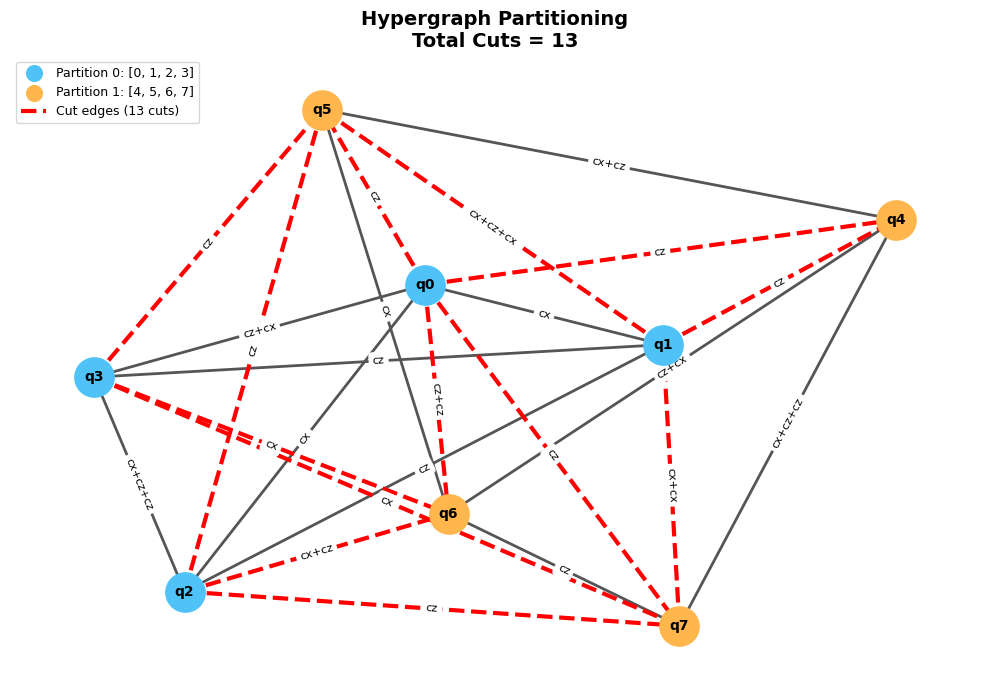

In [10]:
def draw_hypergraph_partition(
        G,
        partition,
        cut_edges_list,
        title="Hypergraph Partition"):

    fig, ax = plt.subplots(figsize=(10, 7))

    pos = nx.spring_layout(G, seed=42, k=1.5)

    cut_edge_set = {(u, v) for u, v, _ in cut_edges_list} | \
                   {(v, u) for u, v, _ in cut_edges_list}

    internal_edges = [
        (u, v)
        for u, v in G.edges()
        if (u, v) not in cut_edge_set
    ]

    cut_edges_draw = [
        (u, v)
        for u, v in G.edges()
        if (u, v) in cut_edge_set
    ]

    colors = [
        "#4fc3f7",
        "#ffb74d",
        "#81c784",
        "#ba68c8",
        "#ffd54f",
        "#90a4ae"
    ]

    num_parts = max(partition.values()) + 1

    for p in range(num_parts):

        nodes = [
            q
            for q in partition
            if partition[q] == p
        ]

        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=nodes,
            node_color=colors[p % len(colors)],
            node_size=800,
            label=f"Partition {p}: {sorted(nodes)}",
            ax=ax
        )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=internal_edges,
        width=2.0,
        edge_color="#555555",
        ax=ax
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cut_edges_draw,
        width=3.0,
        edge_color="red",
        style="dashed",
        label=f"Cut edges ({len(cut_edges_list)} cuts)",
        ax=ax
    )

    nx.draw_networkx_labels(
        G,
        pos,
        labels={n: f"q{n}" for n in G.nodes()},
        font_size=10,
        font_weight="bold",
        ax=ax
    )

    edge_labels = nx.get_edge_attributes(G, "gate")

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        ax=ax
    )

    ax.legend(
        loc="upper left",
        fontsize=9,
        markerscale=0.4
    )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold"
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()

draw_hypergraph_partition(
    G,
    partition,
    cut_edges,
    title=f"Hypergraph Partitioning\n"
          f"Total Cuts = {len(cut_edges)}"
)

In [11]:
def extract_subcircuit(
        circuit,
        qubit_group,
        cut_edges):

    sorted_group = sorted(qubit_group)

    qubit_map = {
        old: new
        for new, old
        in enumerate(sorted_group)
    }

    sub_qc = QuantumCircuit(
        len(sorted_group)
    )

    cut_pairs = {
        (u, v)
        for u, v, _
        in cut_edges
    } | {
        (v, u)
        for u, v, _
        in cut_edges
    }

    for inst in circuit.data:

        idxs = [
            circuit.qubits.index(q)
            for q in inst.qubits
        ]

        if len(idxs) == 1:

            if idxs[0] in qubit_group:

                sub_qc.append(
                    inst.operation,
                    [qubit_map[idxs[0]]]
                )

        elif len(idxs) == 2:

            q0, q1 = idxs

            if (
                q0 in qubit_group
                and
                q1 in qubit_group
            ):

                if (
                    q0,
                    q1
                ) not in cut_pairs:

                    sub_qc.append(
                        inst.operation,
                        [
                            qubit_map[q0],
                            qubit_map[q1]
                        ]
                    )

    return sub_qc


Partition 0
Gates: 45
Depth: 15


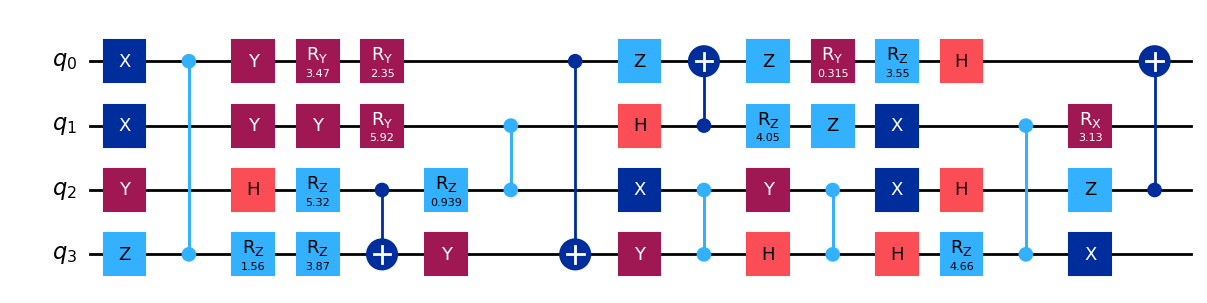


Partition 1
Gates: 45
Depth: 16


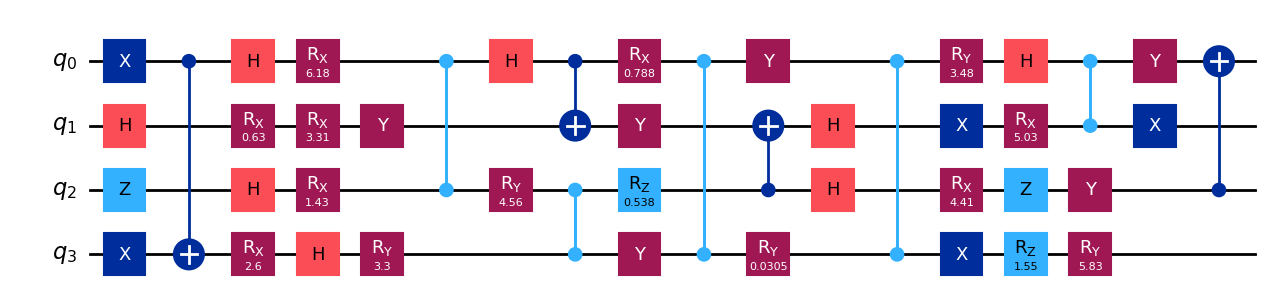

In [12]:
subcircuits = {}

for p in range(num_partitions):

    qubits = {
        q
        for q in partition
        if partition[q] == p
    }

    subcircuits[p] = extract_subcircuit(
        qc,
        qubits,
        cut_edges
    )

for p, sub_qc in subcircuits.items():

    print()
    print(
        f"Partition {p}"
    )

    print(
        f"Gates: {len(sub_qc.data)}"
    )

    print(
        f"Depth: {sub_qc.depth()}"
    )

    display(
        sub_qc.draw("mpl")
    )

Reconstructed Circuit (cut gates removed):
  Original depth     : 18
  Reconstructed depth: 16
  Gates removed      : 18


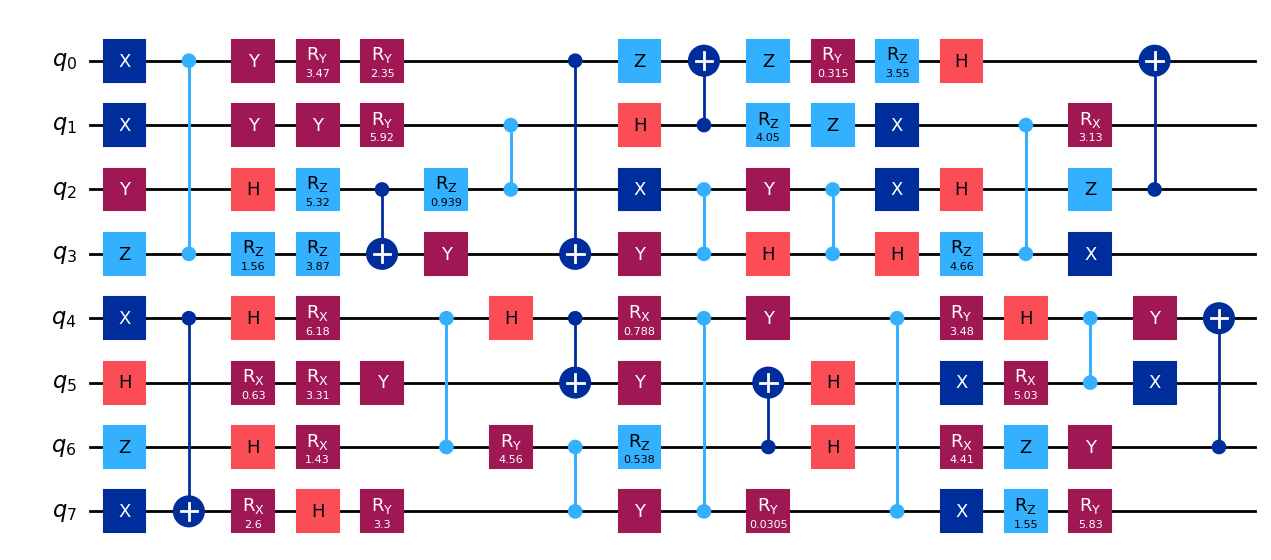

In [15]:
def reconstruct_circuit(circuit, cut_edges):
    
    cut_pairs     = {(u, v) for u, v, _ in cut_edges} | \
                    {(v, u) for u, v, _ in cut_edges}
    reconstructed = QuantumCircuit(circuit.num_qubits)

    for inst in circuit.data:
        idxs = [circuit.qubits.index(q) for q in inst.qubits]
        if len(idxs) == 2 and tuple(idxs) in cut_pairs:
            continue   # skip cut gates
        reconstructed.append(inst.operation, idxs)

    return reconstructed


reconstructed_qc = reconstruct_circuit(qc, cut_edges)

print('Reconstructed Circuit (cut gates removed):')
print(f'  Original depth     : {qc.depth()}')
print(f'  Reconstructed depth: {reconstructed_qc.depth()}')
print(f'  Gates removed      : {len(qc.data) - len(reconstructed_qc.data)}')
reconstructed_qc.draw('mpl', fold=40)

In [19]:
original_sv = Statevector.from_instruction(qc)

reconstructed_sv = \
    Statevector.from_instruction(
        reconstructed_qc
    )

kahypar_fidelity = state_fidelity(
    original_sv,
    reconstructed_sv
)
print()
print('=' * 40)
print('  FIDELITY RESULT')
print('=' * 40)
print(f'  Fidelity = {kahypar_fidelity:.6f}')
print()
if kahypar_fidelity > 0.99:
    print('  Very high — cuts had minimal impact.')
elif kahypar_fidelity > 0.80:
    print('  Moderate — some entanglement lost at cuts.')
else:
    print('  Low — significant entanglement lost at cuts.')
print('=' * 40)
print()
print('Interpretation:')
print('  Fidelity < 1.0 = entanglement lost at cut gates.')
print('  True reconstruction (Pauli decomposition) gives fidelity = 1.0')
print('  at the cost of classical post-processing overhead.')


  FIDELITY RESULT
  Fidelity = 0.009263

  Low — significant entanglement lost at cuts.

Interpretation:
  Fidelity < 1.0 = entanglement lost at cut gates.
  True reconstruction (Pauli decomposition) gives fidelity = 1.0
  at the cost of classical post-processing overhead.
